In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pickle


In [137]:
df=pd.read_csv("/content/student_performance_updated_1000.csv")

In [138]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [139]:
df.tail()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True
999,8021.0,Maria Walls,Female,88.0,10.0,90.0,1.0,Medium,NaN,2.4,94.0,True


In [140]:
df.shape

(1000, 12)

In [141]:
df.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


In [143]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [144]:
df.isnull().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


In [145]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [146]:
df.fillna(df.mode().iloc[0],inplace=True)

/tmp/ipykernel_2977/3910760516.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(df.mode().iloc[0],inplace=True)


In [147]:
df.duplicated().sum()

np.int64(0)

In [148]:
np.int64(0)

np.int64(0)

In [149]:
df.isnull().sum()

,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Study Hours,0


In [150]:
df.drop_duplicates(inplace=True)

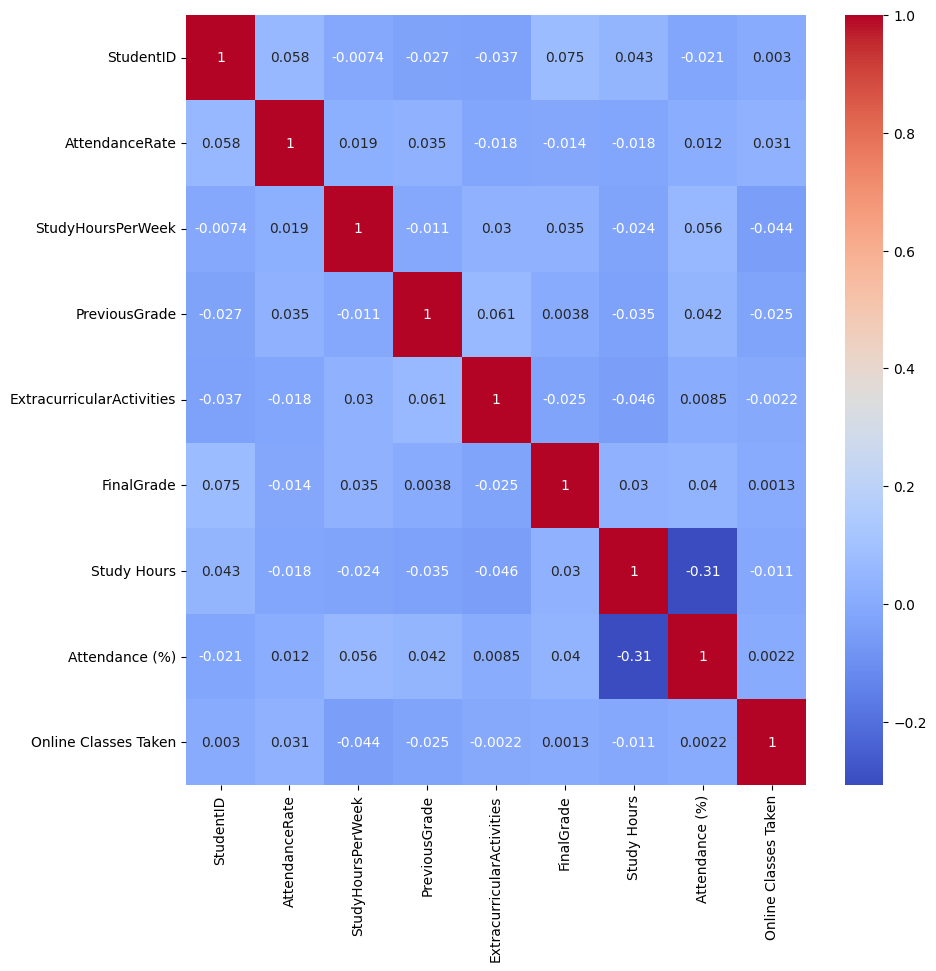

In [151]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

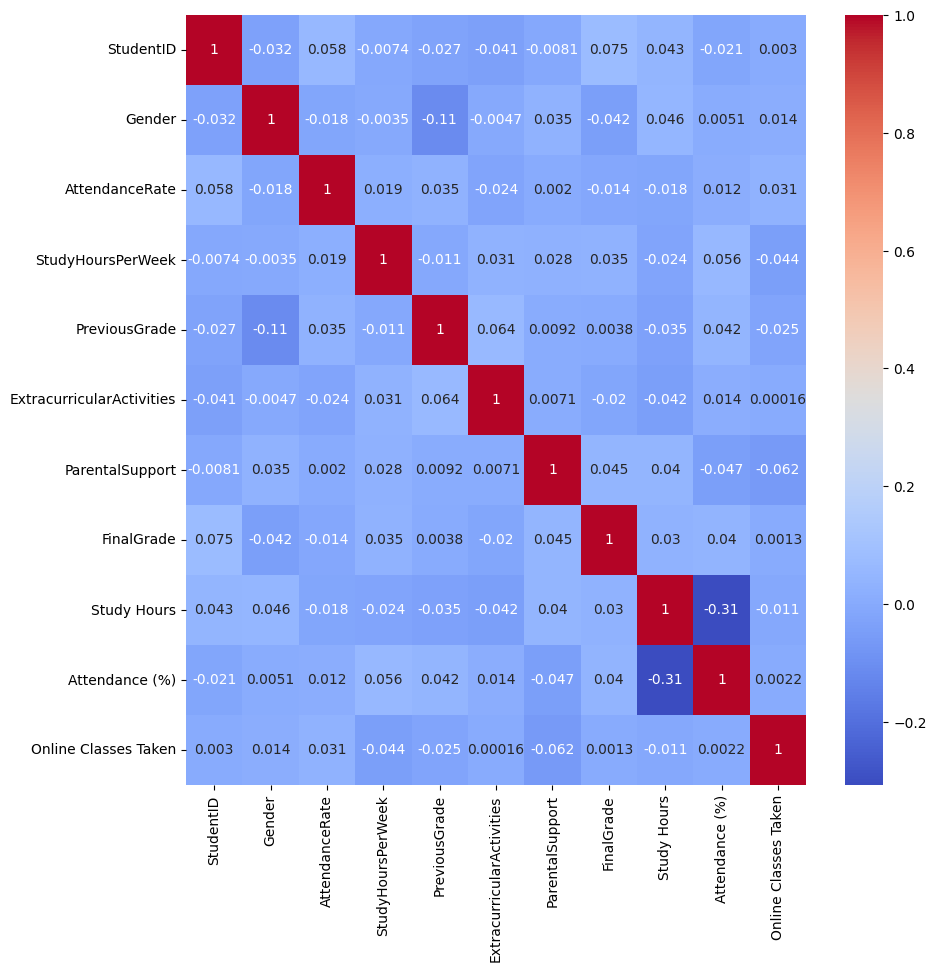

In [152]:
temp =df.copy()
le = LabelEncoder()
temp["Gender"] = le.fit_transform(temp["Gender"])
temp["ExtracurricularActivities"] = le.fit_transform(temp["ExtracurricularActivities"])
temp["ParentalSupport"] = le.fit_transform(temp["ParentalSupport"])
plt.figure(figsize=(10,10))
sns.heatmap(temp.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

<Axes: xlabel='FinalGrade', ylabel='Count'>

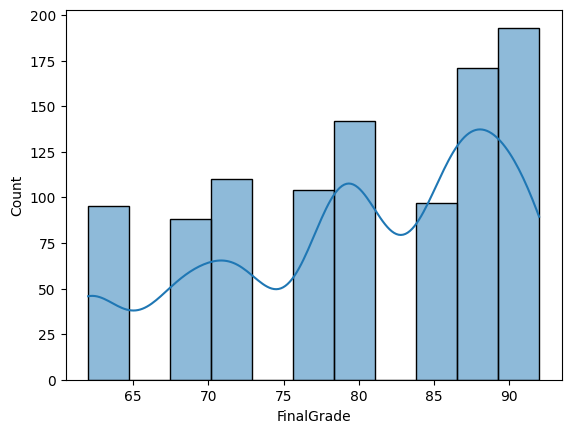

In [153]:
sns.histplot(df["FinalGrade"],kde=True)

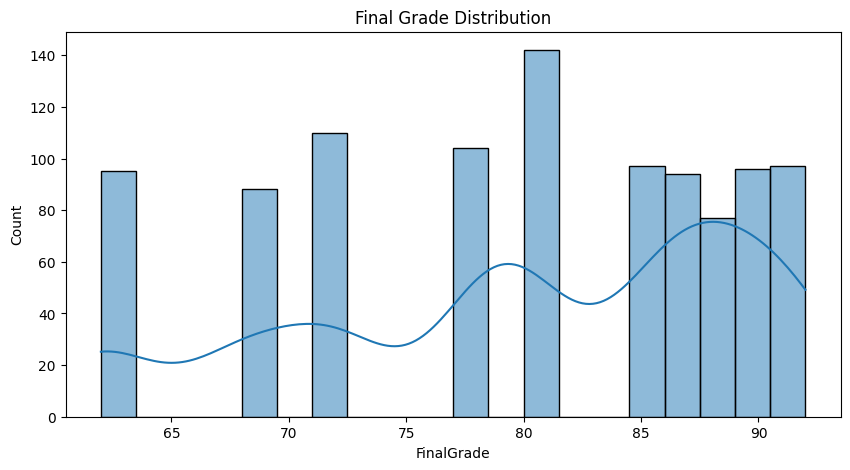

In [154]:
plt.figure(figsize=(10,5))
sns.histplot(df["FinalGrade"],bins=20,kde=True)
plt.title("Final Grade Distribution")
plt.show()

<Axes: xlabel='AttendanceRate', ylabel='FinalGrade'>

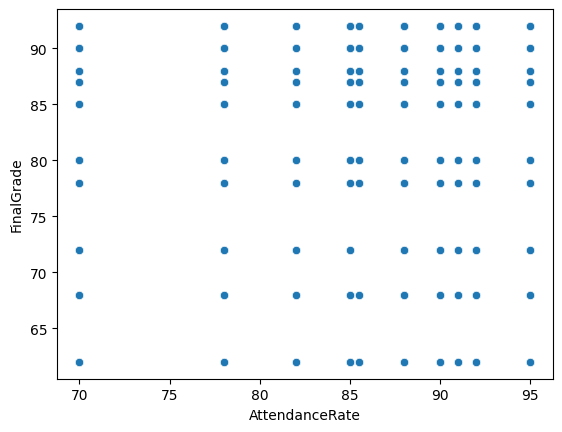

In [155]:
sns.scatterplot(x="AttendanceRate",y="FinalGrade",data=df)

<Axes: xlabel='Study Hours', ylabel='FinalGrade'>

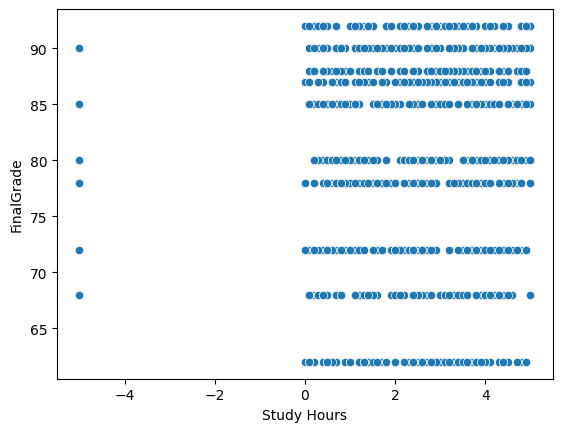

In [156]:
sns.scatterplot(x="Study Hours",y="FinalGrade",data=df)

<Axes: ylabel='FinalGrade'>

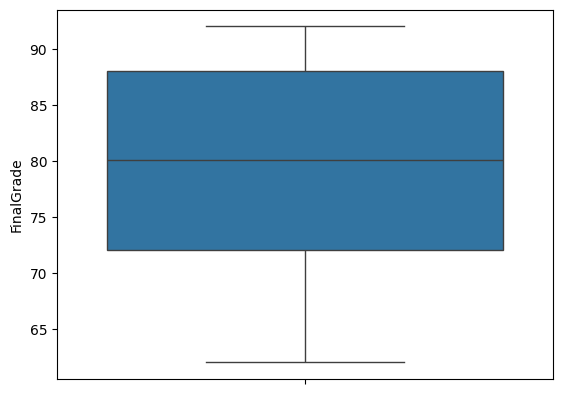

In [157]:
sns.boxplot(df["FinalGrade"])

<Axes: xlabel='Gender', ylabel='count'>

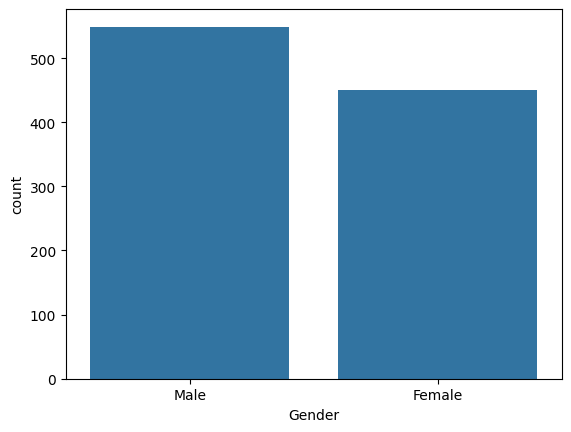

In [158]:
sns.countplot(x="Gender",data=df)

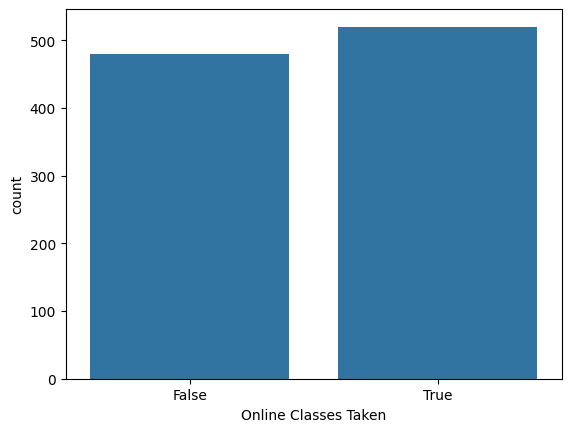

In [159]:
sns.countplot(x="Online Classes Taken",data=df)
plt.show()

In [160]:
le =LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["ExtracurricularActivities"]=le.fit_transform(df["ExtracurricularActivities"])
df["Online Classes Taken"]=le.fit_transform(df["Online Classes Taken"])
df["ParentalSupport"]=le.fit_transform(df["ParentalSupport"])

In [161]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,1,85.000000,15.0,78.0,1,0,80.0,4.8,59.0,0
1,2.0,Sarah,0,90.000000,20.0,85.0,3,2,87.0,2.2,70.0,1
2,3.0,Alex,1,78.000000,10.0,65.0,0,1,68.0,4.6,92.0,0
3,4.0,Michael,1,92.000000,25.0,90.0,4,0,92.0,2.9,96.0,0
4,5.0,Emma,0,85.510417,18.0,82.0,3,2,85.0,4.1,97.0,1


In [162]:
x=df.drop(['StudentID','Name','FinalGrade'],axis=1)
y=df['FinalGrade']

In [163]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [164]:
lr =LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [165]:
lr_pred=lr.predict(x_test)

In [166]:
mae=mean_absolute_error(y_test,lr_pred)
mse=mean_squared_error(y_test,lr_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,lr_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 8.037859907685721
MSE: 91.13306023111168
RMSE: 9.546363717725807
R2: -0.014908784347073656


In [167]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)
print(r2_score(y_test,dt_pred))

-0.9277960810072949


In [168]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print(r2_score(y_test,rf_pred))

-0.03661309479734731


In [169]:
models={
    "Linear Regression":lr,
    "Decision Tree":dt,
    "Random Forest":rf
}
for name,model in models.items():
  pred=model.predict(x_test)
  print(name)
  print("R2 :",r2_score(y_test,pred))
  print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
  print("----------------")

Linear Regression
R2 : -0.014908784347073656
RMSE: 9.546363717725807
----------------
Decision Tree
R2 : -0.9277960810072949
RMSE: 13.156943745935983
----------------
Random Forest
R2 : -0.03661309479734731
RMSE: 9.64790051632542
----------------


In [170]:
importance=pd.DataFrame({"Feature":x.columns,"Importance":rf.feature_importances_})
importance=importance.sort_values(by="Importance",ascending=False)

print(importance)


                     Feature  Importance
7             Attendance (%)    0.213526
6                Study Hours    0.196795
2          StudyHoursPerWeek    0.136580
3              PreviousGrade    0.129091
1             AttendanceRate    0.121825
4  ExtracurricularActivities    0.083277
5            ParentalSupport    0.057072
0                     Gender    0.032776
8       Online Classes Taken    0.029059


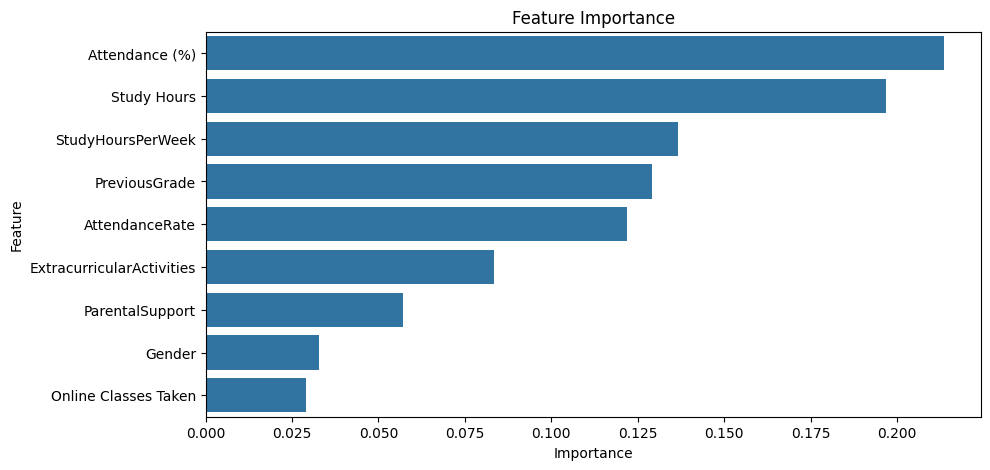

In [171]:
plt.figure(figsize=(10,5))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.show()

In [172]:
pickle.dump(rf,open("student_score_predictor.pkl","wb"))

In [173]:
model=pickle.load(open("student_score_predictor.pkl","rb"))

In [174]:
sample=pd.DataFrame({
    "Gender":[1],
    "AttendanceRate":[85.0],
    "StudyHoursPerWeek":[3.0],
    "PreviousGrade":[82],
    "ExtracurricularActivities":[1],
    "ParentalSupport":[0],
    "Study Hours":[6],
    "Attendance (%)":[90],
    "Online Classes Taken":[1]
})
prediction=model.predict(sample)
print("predicted final score:",prediction[0])

predicted final score: 78.82120833333335


In [175]:
pickle.dump(lr,open("student_score_predictor.pkl","wb"))

In [176]:
model1=pickle.load(open("student_score_predictor.pkl","rb"))

In [177]:
sample1=pd.DataFrame({
    "Gender":[1],
    "AttendanceRate":[85.0],
    "StudyHoursPerWeek":[3.0],
    "PreviousGrade":[82],
    "ExtracurricularActivities":[1],
    "ParentalSupport":[0],
    "Study Hours":[6],
    "Attendance (%)":[90],
    "Online Classes Taken":[1]
})
prediction=model.predict(sample)
print("predicted final score:",prediction[0])

predicted final score: 78.82120833333335
